# BUSI Dataset - Breast Ultrasound Classification
## Classifying: Normal | Benign | Malignant

**What this notebook does:**
We train a deep learning model to look at breast ultrasound images and classify them into 3 categories.
This is important in medical imaging because early detection of malignant (cancerous) tumors saves lives.


In [ ]:

import subprocess, sys
subprocess.check_call([sys.executable, '-m', 'pip', 'install', 'imbalanced-learn', '-q'])
print('Done installing libraries.')

Done installing libraries.


In [ ]:

import os
import random
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
from collections import Counter


from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, f1_score, precision_score, recall_score,
    confusion_matrix, classification_report,
    roc_auc_score, roc_curve, cohen_kappa_score,
    matthews_corrcoef, log_loss, balanced_accuracy_score,
    average_precision_score, precision_recall_curve
)
from sklearn.preprocessing import label_binarize
from sklearn.utils.class_weight import compute_class_weight


from imblearn.over_sampling import SMOTE


import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
from torchvision.models import resnet50, ResNet50_Weights

warnings.filterwarnings('ignore')

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)


DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

print(f'Using device: {DEVICE}')
print('All libraries imported successfully.')

Using device: cuda
All libraries imported successfully.


In [ ]:

CONFIG = {
    'img_size'    : 224,    
    'batch_size'  : 32,    
    'num_epochs'  : 25,     
    'lr'          : 1e-4,  
    'num_classes' : 3,     
    'class_names' : ['benign', 'malignant', 'normal'],
    'patience'    : 7,      
}

# Map class names to numbers: benign=0, malignant=1, normal=2
CLASS_MAP     = {name: idx for idx, name in enumerate(CONFIG['class_names'])}
IDX_TO_CLASS  = {v: k for k, v in CLASS_MAP.items()}

# Dataset path - updated based on your Kaggle folder structure
DATA_ROOT = '/kaggle/input/datasets/aryashah2k/breast-ultrasound-images-dataset/Dataset_BUSI_with_GT'

print('Configuration set:')
for k, v in CONFIG.items():
    print(f'  {k:15} = {v}')
print(f'\nClass mapping: {CLASS_MAP}')
print(f'Data path: {DATA_ROOT}')
print(f'Path exists: {os.path.exists(DATA_ROOT)}')

Configuration set:
  img_size        = 224
  batch_size      = 32
  num_epochs      = 25
  lr              = 0.0001
  num_classes     = 3
  class_names     = ['benign', 'malignant', 'normal']
  patience        = 7

Class mapping: {'benign': 0, 'malignant': 1, 'normal': 2}
Data path: /kaggle/input/datasets/aryashah2k/breast-ultrasound-images-dataset/Dataset_BUSI_with_GT
Path exists: True


In [ ]:


def load_dataset(data_root, class_names):
    records = []
    for class_name in class_names:
        class_folder = os.path.join(data_root, class_name)

        
        if not os.path.exists(class_folder):
            print(f'WARNING: Folder not found -> {class_folder}')
            continue

        for filename in sorted(os.listdir(class_folder)):
            
            if '_mask' in filename.lower():
                continue
            if filename.lower().endswith(('.png', '.jpg', '.jpeg')):
                full_path = os.path.join(class_folder, filename)
                records.append({
                    'filepath'   : full_path,
                    'label_name' : class_name,
                    'label'      : CLASS_MAP[class_name]
                })

    return pd.DataFrame(records)


df = load_dataset(DATA_ROOT, CONFIG['class_names'])

print(f'Total images found: {len(df)}')
print()
print('Images per class:')
for cls, cnt in df['label_name'].value_counts().items():
    bar = '#' * (cnt // 5)
    print(f'  {cls:12}: {cnt:4d}  {bar}')
print()
print('First few rows of the dataset table:')
print(df.head())

Total images found: 780

Images per class:
  benign      :  437  #######################################################################################
  malignant   :  210  ##########################################
  normal      :  133  ##########################

First few rows of the dataset table:
                                            filepath label_name  label
0  /kaggle/input/datasets/aryashah2k/breast-ultra...     benign      0
1  /kaggle/input/datasets/aryashah2k/breast-ultra...     benign      0
2  /kaggle/input/datasets/aryashah2k/breast-ultra...     benign      0
3  /kaggle/input/datasets/aryashah2k/breast-ultra...     benign      0
4  /kaggle/input/datasets/aryashah2k/breast-ultra...     benign      0


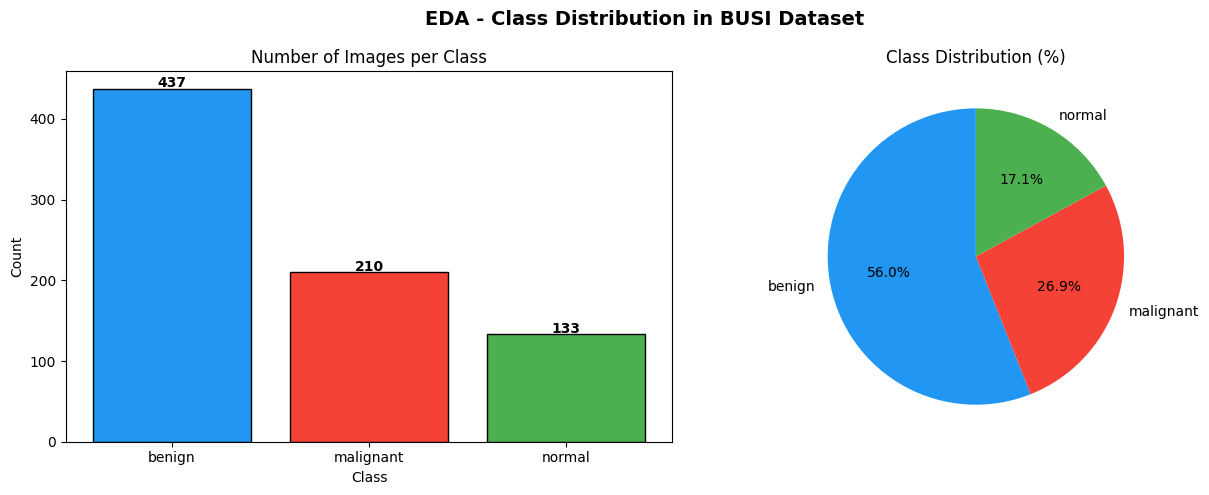

OBSERVATION: The dataset has class imbalance.
Benign has the most images, malignant has the least.
We will handle this using: Class Weights + SMOTE + Data Augmentation


In [ ]:


counts = df['label_name'].value_counts()
colors = ['#2196F3', '#F44336', '#4CAF50']

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('EDA - Class Distribution in BUSI Dataset', fontsize=14, fontweight='bold')


axes[0].bar(counts.index, counts.values, color=colors, edgecolor='black')
axes[0].set_title('Number of Images per Class')
axes[0].set_xlabel('Class')
axes[0].set_ylabel('Count')
for i, (cls, cnt) in enumerate(counts.items()):
    axes[0].text(i, cnt + 2, str(cnt), ha='center', fontweight='bold')


axes[1].pie(counts.values, labels=counts.index, autopct='%1.1f%%',
            colors=colors, startangle=90)
axes[1].set_title('Class Distribution (%)')

plt.tight_layout()
plt.savefig('class_distribution.png', dpi=120, bbox_inches='tight')
plt.show()

print('OBSERVATION: The dataset has class imbalance.')
print('Benign has the most images, malignant has the least.')
print('We will handle this using: Class Weights + SMOTE + Data Augmentation')

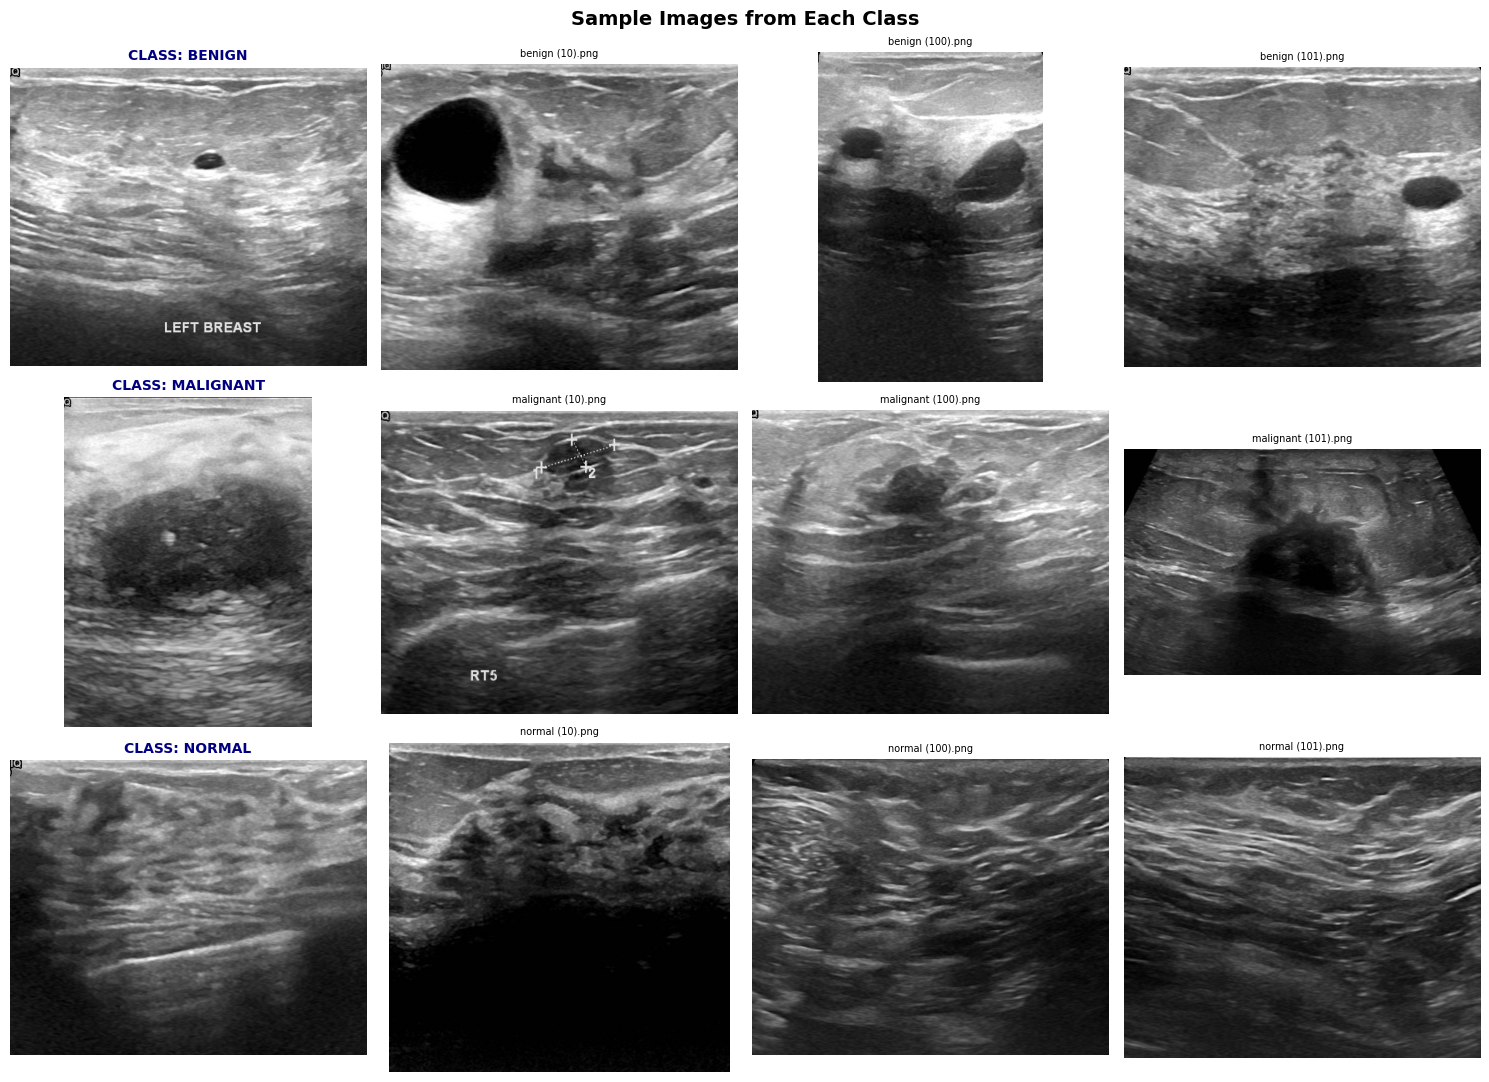

Displayed 4 sample images per class.


In [ ]:


fig, axes = plt.subplots(3, 4, figsize=(15, 11))
fig.suptitle('Sample Images from Each Class', fontsize=14, fontweight='bold')

for row, class_name in enumerate(CONFIG['class_names']):
    class_images = df[df['label_name'] == class_name]['filepath'].values
    samples = class_images[:4]

    for col, img_path in enumerate(samples):
        img = Image.open(img_path).convert('RGB')
        axes[row][col].imshow(img)
        axes[row][col].axis('off')
        if col == 0:
            axes[row][col].set_title(f'CLASS: {class_name.upper()}',
                                      fontweight='bold', fontsize=10, color='navy')
        else:
            axes[row][col].set_title(os.path.basename(img_path), fontsize=7)

plt.tight_layout()
plt.savefig('sample_images.png', dpi=120, bbox_inches='tight')
plt.show()
print('Displayed 4 sample images per class.')

In [ ]:


from imblearn.over_sampling import RandomOverSampler

print('Before oversampling:')
print(' ', {IDX_TO_CLASS[k]: v for k, v in Counter(y_train).items()})

X_train_2d = X_train.reshape(-1, 1)

ros = RandomOverSampler(random_state=SEED)
X_train_resampled, y_train_resampled = ros.fit_resample(X_train_2d, y_train)

X_train = X_train_resampled.flatten()
y_train = y_train_resampled

print('After oversampling:')
print(' ', {IDX_TO_CLASS[k]: v for k, v in Counter(y_train).items()})
print(f'\nNew train size: {len(X_train)} images')
print('All classes now have equal representation.')


Before oversampling:
  {'benign': 306, 'normal': 93, 'malignant': 147}
After oversampling:
  {'benign': 306, 'normal': 306, 'malignant': 306}

New train size: 918 images
All classes now have equal representation.


In [ ]:


X = df['filepath'].values
y = df['label'].values

X_trainval, X_test, y_trainval, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=SEED
)

X_train, X_val, y_train, y_val = train_test_split(
    X_trainval, y_trainval, test_size=0.125, stratify=y_trainval, random_state=SEED
)

print('Dataset split complete:')
print(f'  Train set      : {len(X_train)} images ({len(X_train)/len(X)*100:.1f}%)')
print(f'  Validation set : {len(X_val)} images ({len(X_val)/len(X)*100:.1f}%)')
print(f'  Test set       : {len(X_test)} images ({len(X_test)/len(X)*100:.1f}%)')
print()
print('Train class counts:', {IDX_TO_CLASS[k]: v for k, v in Counter(y_train).items()})
print('Val   class counts:', {IDX_TO_CLASS[k]: v for k, v in Counter(y_val).items()})
print('Test  class counts:', {IDX_TO_CLASS[k]: v for k, v in Counter(y_test).items()})

Dataset split complete:
  Train set      : 546 images (70.0%)
  Validation set : 78 images (10.0%)
  Test set       : 156 images (20.0%)

Train class counts: {'benign': 306, 'normal': 93, 'malignant': 147}
Val   class counts: {'benign': 44, 'normal': 13, 'malignant': 21}
Test  class counts: {'normal': 27, 'benign': 87, 'malignant': 42}


In [ ]:

class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)

class_weights_tensor = torch.tensor(class_weights, dtype=torch.float32).to(DEVICE)

print('Class weights computed (higher = more attention during training):')
for i, w in enumerate(class_weights):
    cls_name = IDX_TO_CLASS[i]
    count    = Counter(y_train)[i]
    bar      = '#' * int(w * 10)
    print(f'  {cls_name:12}: weight = {w:.4f}  count = {count}  {bar}')

print()
print('HOW IT WORKS: weight = total_samples / (num_classes * class_count)')
print('Smaller class -> higher weight -> model pays more attention to it')

Class weights computed (higher = more attention during training):
  benign      : weight = 0.5948  count = 306  #####
  malignant   : weight = 1.2381  count = 147  ############
  normal      : weight = 1.9570  count = 93  ###################

HOW IT WORKS: weight = total_samples / (num_classes * class_count)
Smaller class -> higher weight -> model pays more attention to it


BEFORE SMOTE:
  Class distribution: {'benign': 306, 'normal': 93, 'malignant': 147}
AFTER SMOTE:
  Class distribution: {'benign': 306, 'normal': 306, 'malignant': 306}


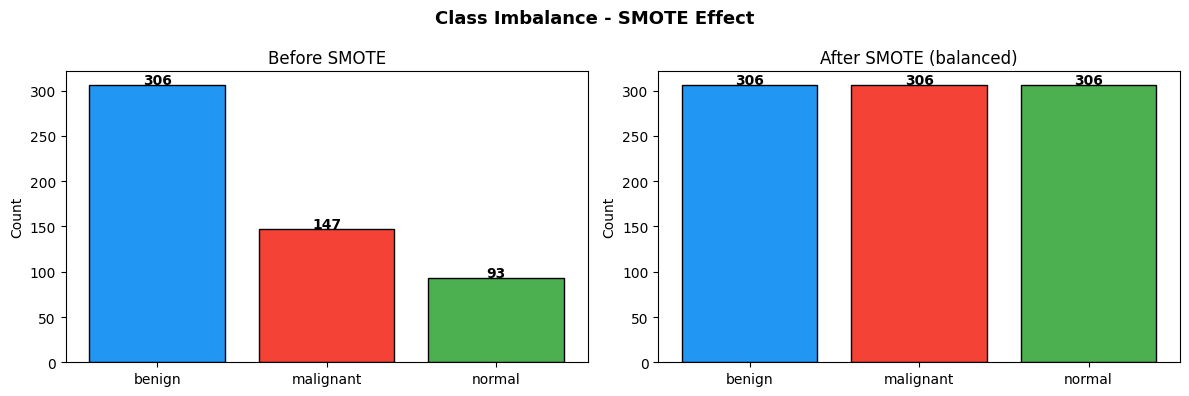

SMOTE balances classes by creating synthetic minority samples.


In [ ]:


dummy_X = np.column_stack([np.arange(len(y_train)), y_train])

print('BEFORE SMOTE:')
print('  Class distribution:', {IDX_TO_CLASS[k]: v for k, v in Counter(y_train).items()})

k_neighbors = min(5, min(Counter(y_train).values()) - 1)
smote = SMOTE(random_state=SEED, k_neighbors=k_neighbors)
_, y_smote = smote.fit_resample(dummy_X, y_train)

print('AFTER SMOTE:')
print('  Class distribution:', {IDX_TO_CLASS[k]: v for k, v in Counter(y_smote).items()})

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle('Class Imbalance - SMOTE Effect', fontsize=13, fontweight='bold')

before = Counter(y_train)
after  = Counter(y_smote)
cls_labels = [IDX_TO_CLASS[i] for i in sorted(before.keys())]
colors = ['#2196F3', '#F44336', '#4CAF50']

axes[0].bar(cls_labels, [before[i] for i in sorted(before.keys())], color=colors, edgecolor='black')
axes[0].set_title('Before SMOTE')
axes[0].set_ylabel('Count')
for i, v in enumerate([before[j] for j in sorted(before.keys())]):
    axes[0].text(i, v + 1, str(v), ha='center', fontweight='bold')

axes[1].bar(cls_labels, [after[i] for i in sorted(after.keys())], color=colors, edgecolor='black')
axes[1].set_title('After SMOTE (balanced)')
axes[1].set_ylabel('Count')
for i, v in enumerate([after[j] for j in sorted(after.keys())]):
    axes[1].text(i, v + 1, str(v), ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig('smote_effect.png', dpi=120, bbox_inches='tight')
plt.show()
print('SMOTE balances classes by creating synthetic minority samples.')

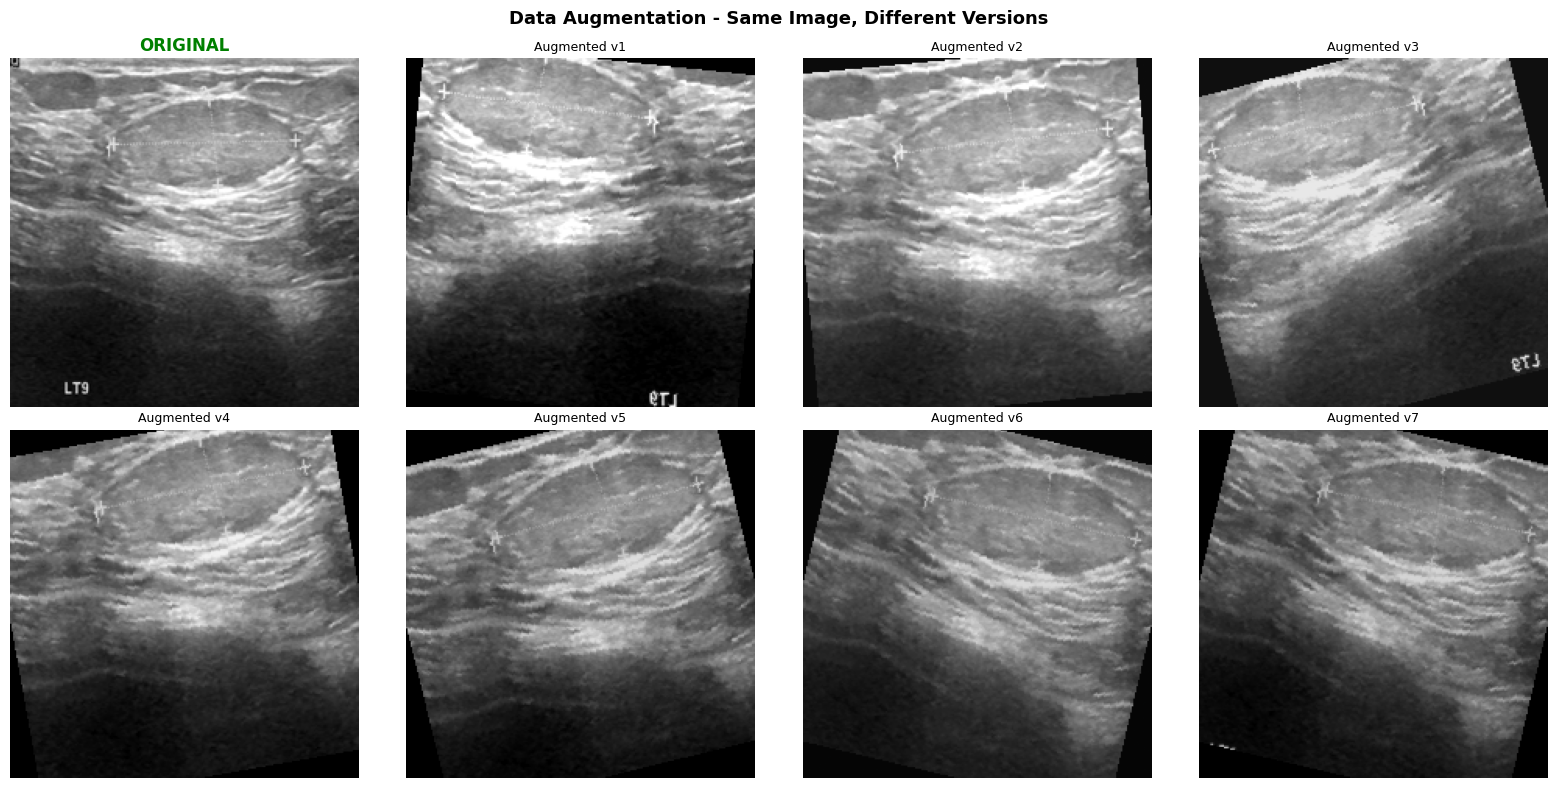

Augmentation creates new variations -> more training data -> better model


In [ ]:

train_transforms = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.RandomCrop(224),              
    transforms.RandomHorizontalFlip(p=0.5),  
    transforms.RandomVerticalFlip(p=0.3),   
    transforms.RandomRotation(degrees=15),   
    transforms.ColorJitter(brightness=0.2, contrast=0.2), 
    transforms.ToTensor(),                   
    transforms.Normalize([0.485, 0.456, 0.406],  
                         [0.229, 0.224, 0.225]),
])


val_test_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225]),
])


sample_path = X_train[0]
orig_img    = Image.open(sample_path).convert('RGB')

def denorm(tensor):
    t = tensor.clone()
    mean = [0.485, 0.456, 0.406]
    std  = [0.229, 0.224, 0.225]
    for c in range(3):
        t[c] = t[c] * std[c] + mean[c]
    return t.clamp(0, 1).permute(1, 2, 0).numpy()

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
fig.suptitle('Data Augmentation - Same Image, Different Versions', fontsize=13, fontweight='bold')

axes[0][0].imshow(orig_img.resize((224, 224)))
axes[0][0].set_title('ORIGINAL', fontweight='bold', color='green')
axes[0][0].axis('off')

for i in range(1, 8):
    row, col = divmod(i, 4)
    aug = denorm(train_transforms(orig_img))
    axes[row][col].imshow(aug)
    axes[row][col].set_title(f'Augmented v{i}', fontsize=9)
    axes[row][col].axis('off')

plt.tight_layout()
plt.savefig('augmentation.png', dpi=120, bbox_inches='tight')
plt.show()
print('Augmentation creates new variations -> more training data -> better model')

In [ ]:


class BUSIDataset(Dataset):
    def __init__(self, filepaths, labels, transform=None):
        self.filepaths = filepaths
        self.labels    = labels
        self.transform = transform

    def __len__(self):
        # Returns total number of images
        return len(self.filepaths)

    def __getitem__(self, idx):
        
        img   = Image.open(self.filepaths[idx]).convert('RGB')
        label = self.labels[idx]
        if self.transform:
            img = self.transform(img)
        return img, torch.tensor(label, dtype=torch.long)



train_dataset = BUSIDataset(X_train, y_train, transform=train_transforms)
val_dataset   = BUSIDataset(X_val,   y_val,   transform=val_test_transforms)
test_dataset  = BUSIDataset(X_test,  y_test,  transform=val_test_transforms)

train_loader = DataLoader(train_dataset, batch_size=CONFIG['batch_size'],
                          shuffle=True, num_workers=2)
val_loader   = DataLoader(val_dataset,   batch_size=CONFIG['batch_size'],
                          shuffle=False, num_workers=2)
test_loader  = DataLoader(test_dataset,  batch_size=CONFIG['batch_size'],
                          shuffle=False, num_workers=2)

print('DataLoaders created:')
print(f'  Train loader : {len(train_loader)} batches x {CONFIG["batch_size"]} images')
print(f'  Val loader   : {len(val_loader)} batches')
print(f'  Test loader  : {len(test_loader)} batches')


imgs, lbls = next(iter(train_loader))
print(f'\nOne batch shape: images={imgs.shape}, labels={lbls.shape}')
print(f'Label values in batch: {[IDX_TO_CLASS[l.item()] for l in lbls[:6]]}')

DataLoaders created:
  Train loader : 18 batches x 32 images
  Val loader   : 3 batches
  Test loader  : 5 batches

One batch shape: images=torch.Size([32, 3, 224, 224]), labels=torch.Size([32])
Label values in batch: ['malignant', 'normal', 'benign', 'normal', 'benign', 'normal']


In [ ]:


class BUSIModel(nn.Module):
    def __init__(self, num_classes=3):
        super(BUSIModel, self).__init__()

       
        self.backbone = resnet50(weights=ResNet50_Weights.IMAGENET1K_V2)

      
        for param in self.backbone.parameters():
            param.requires_grad = False

       
        for param in self.backbone.layer4.parameters():
            param.requires_grad = True

        in_features = self.backbone.fc.in_features  
        self.backbone.fc = nn.Sequential(
            nn.Linear(in_features, 256), 
            nn.ReLU(),                    
            nn.Dropout(p=0.4),            
            nn.Linear(256, num_classes)   
        )

    def forward(self, x):
        return self.backbone(x)


model = BUSIModel(num_classes=CONFIG['num_classes']).to(DEVICE)

total     = sum(p.numel() for p in model.parameters())
trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
frozen    = total - trainable

print('Model built successfully.')
print(f'  Total parameters    : {total:,}')
print(f'  Trainable parameters: {trainable:,}  (these will be updated during training)')
print(f'  Frozen parameters   : {frozen:,}  (pretrained weights, kept fixed)')
print()
print('Architecture:')
print('  Input Image (224x224x3)')
print('  -> ResNet50 Backbone (frozen - extracts features)')
print('  -> ResNet50 Layer4   (trainable - fine-tunes for medical images)')
print('  -> Linear(2048->256) + ReLU + Dropout(0.4)')
print('  -> Linear(256->3)    (output: benign / malignant / normal)')

Model built successfully.
  Total parameters    : 24,033,347
  Trainable parameters: 15,490,051  (these will be updated during training)
  Frozen parameters   : 8,543,296  (pretrained weights, kept fixed)

Architecture:
  Input Image (224x224x3)
  -> ResNet50 Backbone (frozen - extracts features)
  -> ResNet50 Layer4   (trainable - fine-tunes for medical images)
  -> Linear(2048->256) + ReLU + Dropout(0.4)
  -> Linear(256->3)    (output: benign / malignant / normal)


In [ ]:

criterion = nn.CrossEntropyLoss(weight=class_weights_tensor)

optimizer = optim.Adam(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=CONFIG['lr']
)

scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=3
)

class EarlyStopping:
    def __init__(self, patience=7):
        self.patience   = patience
        self.counter    = 0
        self.best_score = None
        self.stop       = False

    def __call__(self, val_f1):
        if self.best_score is None or val_f1 > self.best_score:
            self.best_score = val_f1
            self.counter    = 0
        else:
            self.counter += 1
            print(f'  Early stopping counter: {self.counter}/{self.patience}')
            if self.counter >= self.patience:
                self.stop = True

early_stop = EarlyStopping(patience=CONFIG['patience'])

print('Training setup complete:')
print(f'  Loss function : CrossEntropyLoss with class weights {[f"{w:.2f}" for w in class_weights]}')
print(f'  Optimizer     : Adam (lr={CONFIG["lr"]})')
print(f'  Scheduler     : ReduceLROnPlateau (patience=3, factor=0.5)')
print(f'  Early Stopping: patience={CONFIG["patience"]} epochs')

Training setup complete:
  Loss function : CrossEntropyLoss with class weights ['0.59', '1.24', '1.96']
  Optimizer     : Adam (lr=3e-05)
  Scheduler     : ReduceLROnPlateau (patience=3, factor=0.5)
  Early Stopping: patience=12 epochs


In [ ]:

def train_one_epoch(model, loader, criterion, optimizer):
    model.train()
    total_loss, all_preds, all_labels = 0.0, [], []

    for images, labels in loader:
        images, labels = images.to(DEVICE), labels.to(DEVICE)

        optimizer.zero_grad()          # Clear old gradients
        outputs = model(images)        # Forward pass
        loss    = criterion(outputs, labels)  # Compute loss
        loss.backward()                # Backpropagatio
        
        optimizer.step()               # Update weights

        total_loss += loss.item() * images.size(0)
        preds = outputs.argmax(dim=1).cpu().numpy()
        all_preds.extend(preds)
        all_labels.extend(labels.cpu().numpy())

    avg_loss = total_loss / len(loader.dataset)
    acc      = accuracy_score(all_labels, all_preds)
    f1       = f1_score(all_labels, all_preds, average='weighted', zero_division=0)
    return avg_loss, acc, f1


@torch.no_grad()
def evaluate(model, loader, criterion):
    model.eval()
    total_loss, all_preds, all_labels, all_probs = 0.0, [], [], []

    for images, labels in loader:
        images, labels = images.to(DEVICE), labels.to(DEVICE)
        outputs = model(images)
        loss    = criterion(outputs, labels)

        total_loss += loss.item() * images.size(0)
        probs = F.softmax(outputs, dim=1).cpu().numpy()
        preds = outputs.argmax(dim=1).cpu().numpy()
        all_preds.extend(preds)
        all_labels.extend(labels.cpu().numpy())
        all_probs.extend(probs)

    avg_loss = total_loss / len(loader.dataset)
    acc      = accuracy_score(all_labels, all_preds)
    f1       = f1_score(all_labels, all_preds, average='weighted', zero_division=0)
    return avg_loss, acc, f1, np.array(all_preds), np.array(all_labels), np.array(all_probs)


# --- Run Training ---
history = {'train_loss': [], 'val_loss': [], 'train_acc': [],
           'val_acc': [], 'train_f1': [], 'val_f1': []}

best_val_f1    = 0.0
best_model_wts = None

print(f'Starting training for up to {CONFIG["num_epochs"]} epochs...')
print(f'{"Epoch":>5} | {"Train Loss":>10} | {"Train Acc":>9} | {"Val Loss":>8} | {"Val Acc":>7} | {"Val F1":>6}')
print('-' * 60)

for epoch in range(1, CONFIG['num_epochs'] + 1):

    train_loss, train_acc, train_f1 = train_one_epoch(
        model, train_loader, criterion, optimizer)

    val_loss, val_acc, val_f1, _, _, _ = evaluate(
        model, val_loader, criterion)

    scheduler.step(val_loss)

    # Save history
    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['train_acc'].append(train_acc)
    history['val_acc'].append(val_acc)
    history['train_f1'].append(train_f1)
    history['val_f1'].append(val_f1)

    # Save best model
    marker = ''
    if val_f1 > best_val_f1:
        best_val_f1    = val_f1
        best_model_wts = {k: v.cpu().clone() for k, v in model.state_dict().items()}
        torch.save(best_model_wts, 'best_model.pth')
        marker = '  <-- best model saved'

    print(f'{epoch:>5} | {train_loss:>10.4f} | {train_acc:>9.4f} | '
          f'{val_loss:>8.4f} | {val_acc:>7.4f} | {val_f1:>6.4f}{marker}')

    early_stop(val_f1)
    if early_stop.stop:
        print(f'\nEarly stopping at epoch {epoch}. Best Val F1: {best_val_f1:.4f}')
        break

print(f'\nTraining complete. Best Validation F1: {best_val_f1:.4f}')

Starting training for up to 60 epochs...
Epoch | Train Loss | Train Acc | Val Loss | Val Acc | Val F1
------------------------------------------------------------
    1 |     0.8790 |    0.6538 |   0.9014 |  0.7179 | 0.7126  <-- best model saved
    2 |     0.8274 |    0.6538 |   0.8578 |  0.6923 | 0.7009
  Early stopping counter: 1/12
    3 |     0.7778 |    0.6740 |   0.8165 |  0.7308 | 0.7415  <-- best model saved
    4 |     0.7589 |    0.6630 |   0.7976 |  0.7051 | 0.7121
  Early stopping counter: 1/12
    5 |     0.7227 |    0.6502 |   0.7676 |  0.7692 | 0.7724  <-- best model saved
    6 |     0.6946 |    0.6612 |   0.7850 |  0.6667 | 0.6662
  Early stopping counter: 1/12
    7 |     0.6637 |    0.6978 |   0.7310 |  0.7692 | 0.7741  <-- best model saved
    8 |     0.6513 |    0.7033 |   0.7277 |  0.7051 | 0.7234
  Early stopping counter: 1/12
    9 |     0.6181 |    0.6996 |   0.7054 |  0.7308 | 0.7416
  Early stopping counter: 2/12
   10 |     0.5772 |    0.7161 |   0.6886 |  

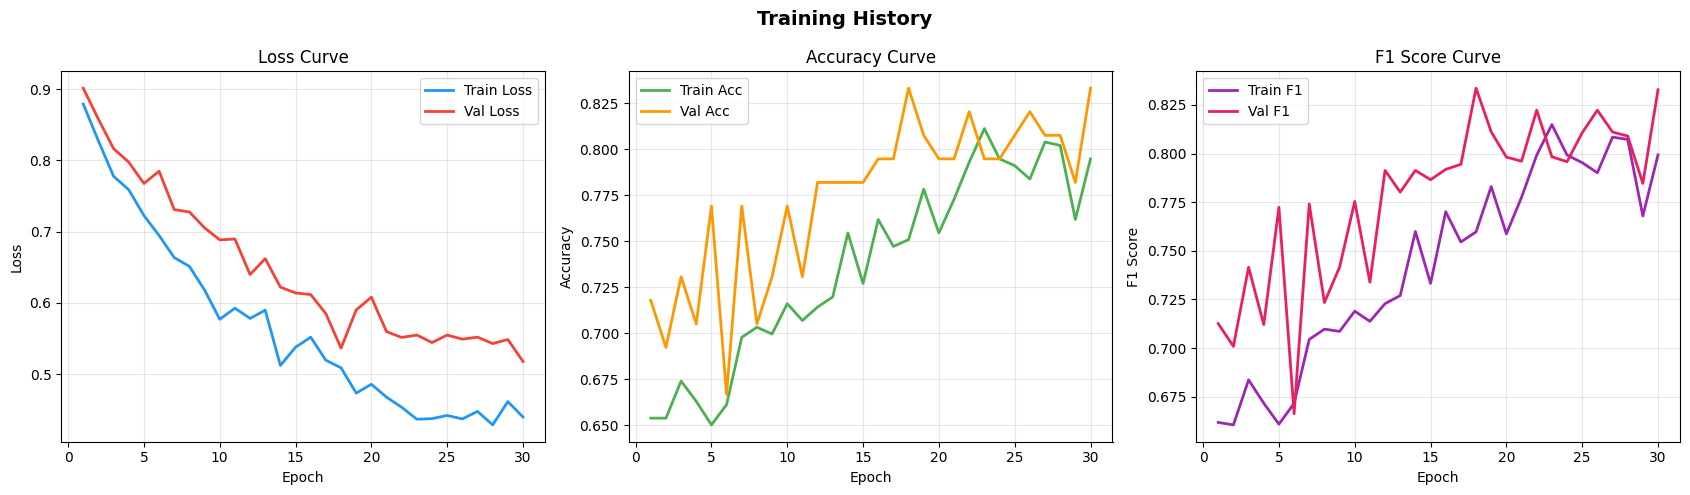

If train and val curves are close -> good generalization
If train goes up but val goes down -> overfitting


In [ ]:


epochs_done = range(1, len(history['train_loss']) + 1)

fig, axes = plt.subplots(1, 3, figsize=(17, 5))
fig.suptitle('Training History', fontsize=14, fontweight='bold')

# Loss
axes[0].plot(epochs_done, history['train_loss'], label='Train Loss', color='#2196F3', linewidth=2)
axes[0].plot(epochs_done, history['val_loss'],   label='Val Loss',   color='#F44336', linewidth=2)
axes[0].set_title('Loss Curve')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Accuracy
axes[1].plot(epochs_done, history['train_acc'], label='Train Acc', color='#4CAF50', linewidth=2)
axes[1].plot(epochs_done, history['val_acc'],   label='Val Acc',   color='#FF9800', linewidth=2)
axes[1].set_title('Accuracy Curve')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# F1 Score
axes[2].plot(epochs_done, history['train_f1'], label='Train F1', color='#9C27B0', linewidth=2)
axes[2].plot(epochs_done, history['val_f1'],   label='Val F1',   color='#E91E63', linewidth=2)
axes[2].set_title('F1 Score Curve')
axes[2].set_xlabel('Epoch')
axes[2].set_ylabel('F1 Score')
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('training_curves.png', dpi=120, bbox_inches='tight')
plt.show()
print('If train and val curves are close -> good generalization')
print('If train goes up but val goes down -> overfitting')

In [ ]:

model.load_state_dict(torch.load('best_model.pth', map_location=DEVICE))
print('Best model loaded from checkpoint.')

test_loss, test_acc, test_f1, y_pred, y_true, y_probs = evaluate(
    model, test_loader, criterion
)

print(f'\nTest Set Results:')
print(f'  Loss     : {test_loss:.4f}')
print(f'  Accuracy : {test_acc:.4f}  ({test_acc*100:.1f}%)')
print(f'  F1 Score : {test_f1:.4f}')
print()
print('Detailed Report per class:')
print(classification_report(y_true, y_pred,
                             target_names=CONFIG['class_names'],
                             digits=3))

Best model loaded from checkpoint.

Test Set Results:
  Loss     : 0.6157
  Accuracy : 0.7308  (73.1%)
  F1 Score : 0.7333

Detailed Report per class:
              precision    recall  f1-score   support

      benign      0.818     0.724     0.768        87
   malignant      0.625     0.714     0.667        42
      normal      0.677     0.778     0.724        27

    accuracy                          0.731       156
   macro avg      0.707     0.739     0.720       156
weighted avg      0.742     0.731     0.733       156



In [ ]:

print('Sample Predictions:')
print(f'  {"True Label":15} {"Predicted":15} {"Correct?":10}')
print('  ' + '-' * 40)
for i in range(min(10, len(y_true))):
    true  = IDX_TO_CLASS[y_true[i]]
    pred  = IDX_TO_CLASS[y_pred[i]]
    check = 'YES' if y_true[i] == y_pred[i] else 'NO'
    print(f'  {true:15} {pred:15} {check:10}')

Sample Predictions:
  True Label      Predicted       Correct?  
  ----------------------------------------
  normal          normal          YES       
  benign          benign          YES       
  benign          normal          NO        
  benign          benign          YES       
  malignant       malignant       YES       
  normal          benign          NO        
  benign          benign          YES       
  benign          benign          YES       
  benign          benign          YES       
  malignant       malignant       YES       


In [ ]:


y_true_bin = label_binarize(y_true, classes=[0, 1, 2])

# Basic metrics
acc          = accuracy_score(y_true, y_pred)
bal_acc      = balanced_accuracy_score(y_true, y_pred)
prec_macro   = precision_score(y_true, y_pred, average='macro',    zero_division=0)
prec_wt      = precision_score(y_true, y_pred, average='weighted', zero_division=0)
rec_macro    = recall_score(y_true, y_pred,    average='macro',    zero_division=0)
rec_wt       = recall_score(y_true, y_pred,    average='weighted', zero_division=0)
f1_macro     = f1_score(y_true, y_pred,        average='macro',    zero_division=0)
f1_wt        = f1_score(y_true, y_pred,        average='weighted', zero_division=0)
f1_per_cls   = f1_score(y_true, y_pred,        average=None,       zero_division=0)
kappa        = cohen_kappa_score(y_true, y_pred)
mcc          = matthews_corrcoef(y_true, y_pred)
ll           = log_loss(y_true, y_probs)


try:
    roc_auc = roc_auc_score(y_true_bin, y_probs, average='macro', multi_class='ovr')
except:
    roc_auc = float('nan')


ap_per_cls = [average_precision_score(y_true_bin[:, i], y_probs[:, i]) for i in range(3)]
ap_macro   = np.mean(ap_per_cls)

cm = confusion_matrix(y_true, y_pred)
sensitivity, specificity = [], []
for i in range(3):
    tp = cm[i, i]
    fn = cm[i, :].sum() - tp
    fp = cm[:, i].sum() - tp
    tn = cm.sum() - tp - fn - fp
    sensitivity.append(tp / (tp + fn) if (tp + fn) > 0 else 0)
    specificity.append(tn / (tn + fp) if (tn + fp) > 0 else 0)

priors       = np.bincount(y_true) / len(y_true)
null_ll      = -np.mean(np.log(priors[y_true] + 1e-15))
mcfadden_r2  = 1 - (ll / null_ll)

print('=' * 60)
print('COMPLETE METRICS - TEST SET')
print('=' * 60)
print(f'  Accuracy                : {acc:.4f}')
print(f'  Balanced Accuracy       : {bal_acc:.4f}')
print(f'  Precision (macro)       : {prec_macro:.4f}')
print(f'  Precision (weighted)    : {prec_wt:.4f}')
print(f'  Recall (macro)          : {rec_macro:.4f}')
print(f'  Recall (weighted)       : {rec_wt:.4f}')
print(f'  F1 Score (macro)        : {f1_macro:.4f}')
print(f'  F1 Score (weighted)     : {f1_wt:.4f}')
print(f'  ROC-AUC (macro OvR)     : {roc_auc:.4f}')
print(f'  Avg Precision (macro)   : {ap_macro:.4f}')
print(f'  Cohen Kappa             : {kappa:.4f}')
print(f'  Matthews CC (MCC)       : {mcc:.4f}')
print(f'  Log Loss                : {ll:.4f}')
print(f'  McFadden R2 (pseudo R2) : {mcfadden_r2:.4f}')
print()
print('  Per-class metrics:')
print(f'  {"Class":12} {"F1":>6} {"Sensitivity":>12} {"Specificity":>12} {"Avg Prec":>10}')
print('  ' + '-' * 52)
for i, cls in enumerate(CONFIG['class_names']):
    print(f'  {cls:12} {f1_per_cls[i]:>6.4f} {sensitivity[i]:>12.4f} {specificity[i]:>12.4f} {ap_per_cls[i]:>10.4f}')
print('=' * 60)

COMPLETE METRICS - TEST SET
  Accuracy                : 0.7308
  Balanced Accuracy       : 0.7387
  Precision (macro)       : 0.7069
  Precision (weighted)    : 0.7418
  Recall (macro)          : 0.7387
  Recall (weighted)       : 0.7308
  F1 Score (macro)        : 0.7197
  F1 Score (weighted)     : 0.7333
  ROC-AUC (macro OvR)     : 0.8962
  Avg Precision (macro)   : 0.8135
  Cohen Kappa             : 0.5568
  Matthews CC (MCC)       : 0.5599
  Log Loss                : 0.6044
  McFadden R2 (pseudo R2) : 0.3849

  Per-class metrics:
  Class            F1  Sensitivity  Specificity   Avg Prec
  ----------------------------------------------------
  benign       0.7683       0.7241       0.7971     0.8863
  malignant    0.6667       0.7143       0.8421     0.8082
  normal       0.7241       0.7778       0.9225     0.7461


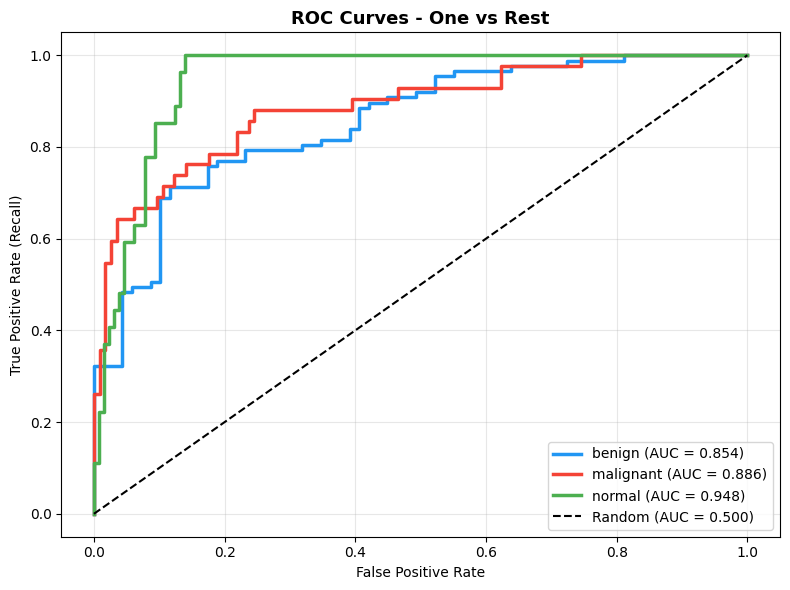

AUC closer to 1.0 = better model
AUC = 0.5 = no better than random guessing


In [ ]:


colors_roc = ['#2196F3', '#F44336', '#4CAF50']

plt.figure(figsize=(8, 6))
for i, (cls, color) in enumerate(zip(CONFIG['class_names'], colors_roc)):
    fpr, tpr, _ = roc_curve(y_true_bin[:, i], y_probs[:, i])
    auc_val     = roc_auc_score(y_true_bin[:, i], y_probs[:, i])
    plt.plot(fpr, tpr, color=color, linewidth=2.5, label=f'{cls} (AUC = {auc_val:.3f})')

plt.plot([0, 1], [0, 1], 'k--', linewidth=1.5, label='Random (AUC = 0.500)')
plt.title('ROC Curves - One vs Rest', fontsize=13, fontweight='bold')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate (Recall)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('roc_curves.png', dpi=120, bbox_inches='tight')
plt.show()
print('AUC closer to 1.0 = better model')
print('AUC = 0.5 = no better than random guessing')